In [1]:
import os
import numpy as np
import efficientnet.tfkeras
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model, model_from_json
from tensorflow.keras import optimizers

os.environ["CUDA_VISIBLE_DEVICES"]= ""

## Load EffNet : 15AB

In [2]:
model_dir = '/media/tohn/HDD/Model_unlearn/Models_USAI/Balance_4/R1/models/B5R1_15AB_fold4_8_NewDataset_balance.h5'
print(f"Load Model: {model_dir}")
model = load_model(model_dir)
height = width = model.input_shape[1]
print(height, width)
model.summary()

Load Model: /media/tohn/HDD/Model_unlearn/Models_USAI/Balance_4/R1/models/B5R1_15AB_fold4_8_NewDataset_balance.h5
456 456
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 456, 456, 3) 0                                            
__________________________________________________________________________________________________
rescaling_1 (Rescaling)         (None, 456, 456, 3)  0           input_2[0][0]                    
__________________________________________________________________________________________________
normalization_1 (Normalization) (None, 456, 456, 3)  7           rescaling_1[0][0]                
__________________________________________________________________________________________________
stem_conv_pad (ZeroPadding2D)   (None, 457, 457, 3)  0           normal

In [3]:
# validation
import pandas as pd
base_dir = '/media/tohn/SSD/Images/Image1'
dataframe = pd.read_csv('/media/tohn/HDD/VISION_dataset/Valdf_fold3_v2.csv')#แก้
validation_dir = os.path.join(base_dir, 'test')

#Train
train_df = pd.read_csv('/media/tohn/HDD/VISION_dataset/Traindf_fold4_8_v2.csv')#แก้
base_dir = '/media/tohn/SSD/Images/Image1'
os.chdir(base_dir)
train_dir = os.path.join(base_dir, 'train')

In [4]:
import pandas as pd
df0 = pd.read_csv('/media/tohn/HDD/VISION_dataset/Testdf_fold1_2_v1.csv')
print(df0 .shape)
dataframe = df0[(df0['Path Crop']!='None' )&(df0['Path Crop']!='Nan')]
print(dataframe.shape)
# print('Normal: ',dataframe[dataframe['Class']=='Normal'].shape)
# print('Abnormal: ',dataframe[dataframe['Class']=='Abnormal'].shape)
dataframe.head(5)

(1312, 27)
(1312, 27)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.513514,0.346614,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.560377,0.428287,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.667984,0.711155,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,0.690385,0.653386,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.672515,0.625498,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3


In [5]:
print(len(set(dataframe['Sub_class_New'])))
print(set(dataframe['Sub_class_New']))

15
{'AB10', 'AB09', 'AB06', 'Normal', 'AB04', 'AB07', 'AB081', 'AB12', 'AB02', 'AB01', 'AB05', 'AB11', 'AB082', 'AB083', 'AB03'}


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 16
train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=30,
      width_shift_range=0.2,
      height_shift_range=0.2,
      brightness_range=[0.5,1.5],
      shear_range=0.4,
      zoom_range=0.2,
      horizontal_flip=False,
      fill_mode='nearest')

train_generator = train_datagen.flow_from_dataframe(
        dataframe = dataframe,
        directory = train_dir,
        x_col = 'Path Crop',
        y_col = 'Sub_class_New',
        target_size = (height, width),
        batch_size=batch_size,
        color_mode= 'rgb',
        class_mode='categorical')

#label
labels = (train_generator.class_indices)
labels = dict((v,k.replace("C","")) for k,v in labels.items())
print(labels)

Found 1312 validated image filenames belonging to 15 classes.
{0: 'AB01', 1: 'AB02', 2: 'AB03', 3: 'AB04', 4: 'AB05', 5: 'AB06', 6: 'AB07', 7: 'AB081', 8: 'AB082', 9: 'AB083', 10: 'AB09', 11: 'AB10', 12: 'AB11', 13: 'AB12', 14: 'Normal'}


# Prediction

In [7]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    # Read the image and resize it
    img = image.load_img(img_path, target_size=(height, width))
    # Convert it to a Numpy array with target shape.
    x = image.img_to_array(img)
    # Reshape
    x = x.reshape((1,) + x.shape)
    x /= 255.
    result = model.predict([x])
    
    return result[0]

#Predict
pred_list = list()
prob_list = list()
img_path=dataframe['Path Crop'].tolist()
for i in range(0,len(img_path)):
    predict = predict_image(img_path[i])
    result = np.argmax(predict)
    pred_list.append(labels[result])
    prob_list.append(predict[result])
    print(f"Predict: image {i+1}")

dataframe['category'] = pred_list
dataframe['Prob'] = prob_list

Predict: image 1
Predict: image 2
Predict: image 3
Predict: image 4
Predict: image 5
Predict: image 6
Predict: image 7
Predict: image 8
Predict: image 9
Predict: image 10
Predict: image 11
Predict: image 12
Predict: image 13
Predict: image 14
Predict: image 15
Predict: image 16
Predict: image 17
Predict: image 18
Predict: image 19
Predict: image 20
Predict: image 21
Predict: image 22
Predict: image 23
Predict: image 24
Predict: image 25
Predict: image 26
Predict: image 27
Predict: image 28
Predict: image 29
Predict: image 30
Predict: image 31
Predict: image 32
Predict: image 33
Predict: image 34
Predict: image 35
Predict: image 36
Predict: image 37
Predict: image 38
Predict: image 39
Predict: image 40
Predict: image 41
Predict: image 42
Predict: image 43
Predict: image 44
Predict: image 45
Predict: image 46
Predict: image 47
Predict: image 48
Predict: image 49
Predict: image 50
Predict: image 51
Predict: image 52
Predict: image 53
Predict: image 54
Predict: image 55
Predict: image 56
P

Predict: image 438
Predict: image 439
Predict: image 440
Predict: image 441
Predict: image 442
Predict: image 443
Predict: image 444
Predict: image 445
Predict: image 446
Predict: image 447
Predict: image 448
Predict: image 449
Predict: image 450
Predict: image 451
Predict: image 452
Predict: image 453
Predict: image 454
Predict: image 455
Predict: image 456
Predict: image 457
Predict: image 458
Predict: image 459
Predict: image 460
Predict: image 461
Predict: image 462
Predict: image 463
Predict: image 464
Predict: image 465
Predict: image 466
Predict: image 467
Predict: image 468
Predict: image 469
Predict: image 470
Predict: image 471
Predict: image 472
Predict: image 473
Predict: image 474
Predict: image 475
Predict: image 476
Predict: image 477
Predict: image 478
Predict: image 479
Predict: image 480
Predict: image 481
Predict: image 482
Predict: image 483
Predict: image 484
Predict: image 485
Predict: image 486
Predict: image 487
Predict: image 488
Predict: image 489
Predict: ima

Predict: image 870
Predict: image 871
Predict: image 872
Predict: image 873
Predict: image 874
Predict: image 875
Predict: image 876
Predict: image 877
Predict: image 878
Predict: image 879
Predict: image 880
Predict: image 881
Predict: image 882
Predict: image 883
Predict: image 884
Predict: image 885
Predict: image 886
Predict: image 887
Predict: image 888
Predict: image 889
Predict: image 890
Predict: image 891
Predict: image 892
Predict: image 893
Predict: image 894
Predict: image 895
Predict: image 896
Predict: image 897
Predict: image 898
Predict: image 899
Predict: image 900
Predict: image 901
Predict: image 902
Predict: image 903
Predict: image 904
Predict: image 905
Predict: image 906
Predict: image 907
Predict: image 908
Predict: image 909
Predict: image 910
Predict: image 911
Predict: image 912
Predict: image 913
Predict: image 914
Predict: image 915
Predict: image 916
Predict: image 917
Predict: image 918
Predict: image 919
Predict: image 920
Predict: image 921
Predict: ima

Predict: image 1287
Predict: image 1288
Predict: image 1289
Predict: image 1290
Predict: image 1291
Predict: image 1292
Predict: image 1293
Predict: image 1294
Predict: image 1295
Predict: image 1296
Predict: image 1297
Predict: image 1298
Predict: image 1299
Predict: image 1300
Predict: image 1301
Predict: image 1302
Predict: image 1303
Predict: image 1304
Predict: image 1305
Predict: image 1306
Predict: image 1307
Predict: image 1308
Predict: image 1309
Predict: image 1310
Predict: image 1311
Predict: image 1312


In [8]:
pred_list

['AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 'AB03',
 

In [9]:
prob_list

[0.17994478,
 0.17993703,
 0.17997076,
 0.17999753,
 0.1799942,
 0.17986324,
 0.17987813,
 0.17990433,
 0.17994528,
 0.17993772,
 0.17989995,
 0.17994739,
 0.17988396,
 0.18010692,
 0.17988563,
 0.17975706,
 0.17993832,
 0.17971633,
 0.17982905,
 0.17973882,
 0.17974277,
 0.17995833,
 0.18002331,
 0.18004102,
 0.17978454,
 0.17984077,
 0.18013497,
 0.18013263,
 0.17994209,
 0.17984779,
 0.1797137,
 0.17965886,
 0.17980568,
 0.17970528,
 0.17991515,
 0.17986146,
 0.17993402,
 0.17994201,
 0.18000415,
 0.17993788,
 0.17991075,
 0.17976137,
 0.17983513,
 0.17996666,
 0.17985049,
 0.17989686,
 0.18003301,
 0.17961845,
 0.17997058,
 0.17974208,
 0.17989326,
 0.17999178,
 0.17989163,
 0.17991175,
 0.17993842,
 0.17997022,
 0.18001054,
 0.17993845,
 0.17994036,
 0.17984025,
 0.17995887,
 0.1798777,
 0.17993341,
 0.18005809,
 0.1797857,
 0.17987148,
 0.17986922,
 0.17986006,
 0.18017566,
 0.17990409,
 0.17994802,
 0.1797592,
 0.17978045,
 0.17977998,
 0.17992236,
 0.17982545,
 0.17986755,
 0.1

# Evaluation

In [10]:
data_train = dataframe
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class_New'])
print('Actual : ',len(classe))
print(classe)

Predicted :  1
{'AB03'}
Actual :  15
{'AB10', 'AB09', 'AB06', 'Normal', 'AB04', 'AB07', 'AB081', 'AB12', 'AB02', 'AB01', 'AB05', 'AB11', 'AB082', 'AB083', 'AB03'}


In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix
act = data_train['Sub_class_New'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 1.4481707317073171%
              precision    recall  f1-score   support

        AB01       0.00      0.00      0.00        74
        AB02       0.00      0.00      0.00        59
        AB03       0.01      1.00      0.03        19
        AB04       0.00      0.00      0.00        38
        AB05       0.00      0.00      0.00        29
        AB06       0.00      0.00      0.00        21
        AB07       0.00      0.00      0.00        21
       AB081       0.00      0.00      0.00        32
       AB082       0.00      0.00      0.00        28
       AB083       0.00      0.00      0.00        11
        AB09       0.00      0.00      0.00        26
        AB10       0.00      0.00      0.00        10
        AB11       0.00      0.00      0.00        55
        AB12       0.00      0.00      0.00        32
      Normal       0.00      0.00      0.00       857

    accuracy                           0.01      1312
   macro avg       0.00      0.07     

/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Text(0.5, 21.5, 'Predicted label')

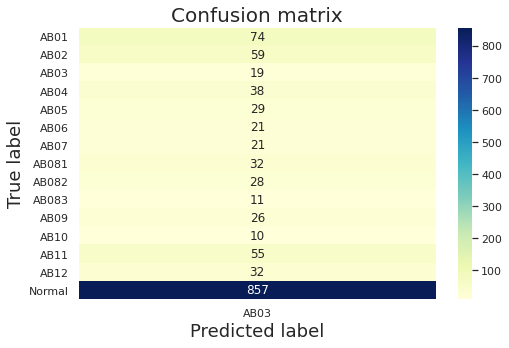

In [12]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

In [13]:
# act= p1['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
act= data_train['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
pred = data_train['category'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 34.67987804878049%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       857
           1       0.35      1.00      0.51       455

    accuracy                           0.35      1312
   macro avg       0.17      0.50      0.26      1312
weighted avg       0.12      0.35      0.18      1312



/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


0 857 0 455


Text(48.5, 0.5, 'True label')

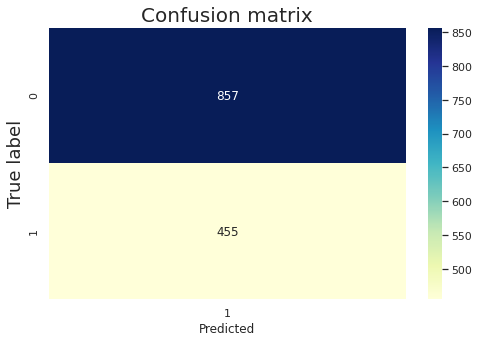

In [14]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)
TN, FP, FN, TP = confusion_matrix(act, pred).ravel()
print(TN, FP, FN, TP)
#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)

In [15]:
Sub_class_New = list(set(dataframe['Sub_class_New']))

for i in range(len(Sub_class_New)):
    df = dataframe[dataframe['Sub_class_New'] == Sub_class_New[i]]
    
    act = df['Sub_class_New'].array
    pred = df['category'].array

    cmat = confusion_matrix(act, pred)
    print('######', Sub_class_New[i])
#     print(cmat)
#     print(classification_report(act, pred))
    
    print('classifier accuracy = {}% \n'.format((np.trace(cmat))/(np.sum(cmat))))

###### AB10
classifier accuracy = 0.0% 

###### AB09
classifier accuracy = 0.0% 

###### AB06
classifier accuracy = 0.0% 

###### Normal
classifier accuracy = 0.0% 

###### AB04
classifier accuracy = 0.0% 

###### AB07
classifier accuracy = 0.0% 

###### AB081
classifier accuracy = 0.0% 

###### AB12
classifier accuracy = 0.0% 

###### AB02
classifier accuracy = 0.0% 

###### AB01
classifier accuracy = 0.0% 

###### AB05
classifier accuracy = 0.0% 

###### AB11
classifier accuracy = 0.0% 

###### AB082
classifier accuracy = 0.0% 

###### AB083
classifier accuracy = 0.0% 

###### AB03
classifier accuracy = 1.0% 



-----------

-------